In [72]:
import duckdb 
import pandas as pd
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt

In [73]:
DB_path = "../../house_prices.duckdb"
con = duckdb.connect(DB_path)

In [74]:
tables = con.execute("SHOW TABLES").df()
print(tables)

                          name
0       epc_data_fully_cleaned
1               epc_kent_clean
2                 epc_kent_raw
3          land_registry_clean
4  land_registry_fully_cleaned
5            land_registry_raw


In [75]:
df_land_registry = con.execute("SELECT * FROM land_registry_fully_cleaned").df()
print(df_land_registry.head())

    price date_of_transfer  postcode property_type new_build_flag duration  \
0  150000       2021-07-23  CT20 2DE             F              N        L   
1  115000       2021-08-03  ME15 6ZL             F              N        L   
2   67500       2021-06-01   TN9 1FT             F              N        L   
3  283000       2021-03-26  ME10 5BJ             S              N        F   
4  358000       2021-05-06  TN10 4JX             S              N        F   

    town           city               district county  
0   None     FOLKESTONE   FOLKESTONE AND HYTHE   KENT  
1  TOVIL      MAIDSTONE              MAIDSTONE   KENT  
2   None      TONBRIDGE  TONBRIDGE AND MALLING   KENT  
3   None  SITTINGBOURNE                  SWALE   KENT  
4   None      TONBRIDGE  TONBRIDGE AND MALLING   KENT  


In [76]:
df_land_registry["postcode"] = (df_land_registry["postcode"].str.upper().str.strip())

In [77]:
df_epc = con.execute("SELECT * FROM epc_data_fully_cleaned").df()
print(df_epc.head())

   POSTCODE  TOTAL_FLOOR_AREA  NUMBER_HABITABLE_ROOMS PROPERTY_TYPE  \
0  CT13 0AL              81.0                       4         House   
1  CT17 0BA              94.0                       5         House   
2  CT17 9FB              46.0                       2          Flat   
3   CT3 3GZ              64.0                       4          Flat   
4   CT3 1FX             139.0                       4         House   

          CONSTRUCTION_AGE_BAND CURRENT_ENERGY_RATING LODGEMENT_DATE  
0  England and Wales: 1950-1966                     D     2021-07-01  
1  England and Wales: 1930-1949                     D     2021-07-01  
2  England and Wales: 1996-2002                     C     2021-07-02  
3                          2021                     B     2021-07-21  
4                          2021                     B     2021-09-21  


In [78]:
df_epc["POSTCODE"] = (df_epc["POSTCODE"].str.upper().str.strip())

In [79]:
df_land_registry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118657 entries, 0 to 118656
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   price             118657 non-null  int64         
 1   date_of_transfer  118657 non-null  datetime64[us]
 2   postcode          117920 non-null  object        
 3   property_type     118657 non-null  object        
 4   new_build_flag    118657 non-null  object        
 5   duration          118657 non-null  object        
 6   town              48978 non-null   object        
 7   city              118657 non-null  object        
 8   district          118657 non-null  object        
 9   county            118657 non-null  object        
dtypes: datetime64[us](1), int64(1), object(8)
memory usage: 9.1+ MB


In [80]:
df_epc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196677 entries, 0 to 196676
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   POSTCODE                196677 non-null  object        
 1   TOTAL_FLOOR_AREA        196677 non-null  float64       
 2   NUMBER_HABITABLE_ROOMS  196677 non-null  int64         
 3   PROPERTY_TYPE           196677 non-null  object        
 4   CONSTRUCTION_AGE_BAND   196677 non-null  object        
 5   CURRENT_ENERGY_RATING   196677 non-null  object        
 6   LODGEMENT_DATE          196677 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), object(4)
memory usage: 10.5+ MB


In [81]:
df_land_registry = df_land_registry.sort_values("date_of_transfer")
df_epc = df_epc.sort_values("LODGEMENT_DATE")

In [82]:
#rename the postcode to match land_registry one to join. 
df_epc.rename(columns={"POSTCODE": "postcode"},inplace=True)
df_epc.rename(columns={"PROPERTY_TYPE": "PROPERTY_TYPE_EPC"},inplace=True)

In [83]:
df_epc.head()

,postcode,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,PROPERTY_TYPE_EPC,CONSTRUCTION_AGE_BAND,CURRENT_ENERGY_RATING,LODGEMENT_DATE
171498,BR6 7QE,180.0,7,House,England and Wales: 1900-1929,E,2021-01-01
62111,ME10 5JT,25.0,2,Flat,England and Wales: 2007-2011,C,2021-01-02
183741,CT2 7RP,85.0,4,House,England and Wales: 1976-1982,E,2021-01-02
75836,DA3 7LX,227.0,7,House,England and Wales: 1900-1929,D,2021-01-02
75837,DA3 7JP,84.0,4,Bungalow,England and Wales: 1950-1966,E,2021-01-02


In [84]:
#merge_asof joins on nearest key instead of exact match 
df_joined = pd.merge_asof(df_land_registry, df_epc, left_on="date_of_transfer", 
                          right_on="LODGEMENT_DATE", by="postcode",direction = "backward")

In [85]:
print((df_joined["LODGEMENT_DATE"] > df_joined["date_of_transfer"]).any())


False


In [86]:
df_joined.isna().sum()

price                         0
date_of_transfer              0
postcode                    737
property_type                 0
new_build_flag                0
duration                      0
town                      69679
city                          0
district                      0
county                        0
TOTAL_FLOOR_AREA          35002
NUMBER_HABITABLE_ROOMS    35002
PROPERTY_TYPE_EPC         35002
CONSTRUCTION_AGE_BAND     35002
CURRENT_ENERGY_RATING     35002
LODGEMENT_DATE            35002
dtype: int64

In [87]:
df_joined.head()



,price,date_of_transfer,postcode,property_type,new_build_flag,duration,town,city,district,county,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,PROPERTY_TYPE_EPC,CONSTRUCTION_AGE_BAND,CURRENT_ENERGY_RATING,LODGEMENT_DATE
0,50000,2021-01-01,ME9 7SP,O,N,F,HARTLIP,SITTINGBOURNE,SWALE,KENT,NaN,NaN,NaN,NaN,NaN,NaT
1,343000,2021-01-04,CT1 3HL,S,N,F,None,CANTERBURY,CANTERBURY,KENT,NaN,NaN,NaN,NaN,NaN,NaT
2,257000,2021-01-04,ME15 6RU,T,N,F,None,MAIDSTONE,MAIDSTONE,KENT,NaN,NaN,NaN,NaN,NaN,NaT
3,400000,2021-01-04,TN27 9EA,S,N,F,EGERTON,ASHFORD,ASHFORD,KENT,NaN,NaN,NaN,NaN,NaN,NaT
4,80000,2021-01-04,CT19 4RL,F,N,L,None,FOLKESTONE,FOLKESTONE AND HYTHE,KENT,NaN,NaN,NaN,NaN,NaN,NaT


In [88]:
df_joined["PROPERTY_TYPE_EPC"].unique()

array([nan, 'Bungalow', 'House', 'Flat', 'Maisonette', 'Park home'],
      dtype=object)

In [89]:
#(S=semi-detached, T= Terraced, F=Flats, D=Detached, O=Others/Commercial)
df_joined["property_type"].unique()

array(['O', 'S', 'T', 'F', 'D'], dtype=object)

In [90]:
#feature engineering date of transfer
df_joined["sale_year"] = df_joined["date_of_transfer"].dt.year
df_joined["quarter"] = df_joined["date_of_transfer"].dt.quarter

In [91]:
#feature engineering property type
df_joined = pd.get_dummies(df_joined, columns=['property_type'],prefix='lr_ptype')

In [92]:
df_joined.head()

,price,date_of_transfer,postcode,new_build_flag,duration,town,city,district,county,TOTAL_FLOOR_AREA,...,CONSTRUCTION_AGE_BAND,CURRENT_ENERGY_RATING,LODGEMENT_DATE,sale_year,quarter,lr_ptype_D,lr_ptype_F,lr_ptype_O,lr_ptype_S,lr_ptype_T
0,50000,2021-01-01,ME9 7SP,N,F,HARTLIP,SITTINGBOURNE,SWALE,KENT,NaN,...,NaN,NaN,NaT,2021,1,False,False,True,False,False
1,343000,2021-01-04,CT1 3HL,N,F,None,CANTERBURY,CANTERBURY,KENT,NaN,...,NaN,NaN,NaT,2021,1,False,False,False,True,False
2,257000,2021-01-04,ME15 6RU,N,F,None,MAIDSTONE,MAIDSTONE,KENT,NaN,...,NaN,NaN,NaT,2021,1,False,False,False,False,True
3,400000,2021-01-04,TN27 9EA,N,F,EGERTON,ASHFORD,ASHFORD,KENT,NaN,...,NaN,NaN,NaT,2021,1,False,False,False,True,False
4,80000,2021-01-04,CT19 4RL,N,L,None,FOLKESTONE,FOLKESTONE AND HYTHE,KENT,NaN,...,NaN,NaN,NaT,2021,1,False,True,False,False,False


In [93]:
#Drop PROPERTY TYPE joined from epc table, because it is too general
df_joined = df_joined.drop(columns=['PROPERTY_TYPE_EPC'])

In [94]:
#check unique value for newly_build_flag 
df_joined['new_build_flag'].unique()

array(['N', 'Y'], dtype=object)

In [95]:
#Map yes and no to binary values 1 and 0
new_build_flag_map = {'Y':1, 'N':0}
df_joined['new_build_flag'] = df_joined['new_build_flag'].map(new_build_flag_map)

In [96]:
#Check the values for duration
df_joined['duration'].unique()

array(['F', 'L'], dtype=object)

In [97]:
#Map Freehold and Leasehold to binary values 1 and 0
duration_map = {'F':1, 'L':0}
df_joined['duration'] = df_joined['duration'].map(duration_map)

In [98]:
#City and district offered no value as each postcode only maps to single district or city 
#Even if tried with one hot encoding these columns appeared to be constant, 
#keeping them would create redundancy and noise
df_joined =df_joined.drop(columns=['city','district','county','town'])

In [99]:
#feature engineering floor area
#add a floor area missing flag and impute the missing rows with median values
#impute with only training data values 
df_joined["floor_area_missing"] = df_joined["TOTAL_FLOOR_AREA"].isna().astype(int)
training_mask = df_joined['sale_year']<2024
median_floor = df_joined.loc[training_mask,'TOTAL_FLOOR_AREA'].median()
df_joined["TOTAL_FLOOR_AREA"] = df_joined["TOTAL_FLOOR_AREA"].fillna(median_floor)

In [100]:
#feature engineering habitable rooms
#add a habitable room missing flag and impute the missing rows with median values
df_joined["habitable_rooms_missing"] = df_joined["NUMBER_HABITABLE_ROOMS"].isna().astype(int)
median_habitable_rooms = df_joined.loc[training_mask,'NUMBER_HABITABLE_ROOMS'].median()
df_joined["NUMBER_HABITABLE_ROOMS"] = df_joined["NUMBER_HABITABLE_ROOMS"].fillna(median_habitable_rooms)

In [101]:
#Engineer to find floor area per room, this helps to know space to room ratio
df_joined['FLOOR_AREA_PER_ROOM'] = df_joined['TOTAL_FLOOR_AREA']/ df_joined['NUMBER_HABITABLE_ROOMS']

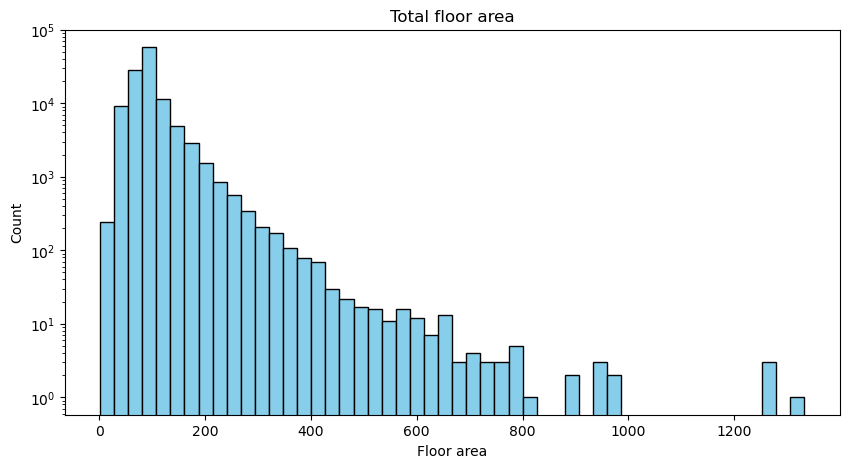

In [102]:
plt.figure(figsize=(10,5))
plt.hist(df_joined['TOTAL_FLOOR_AREA'], bins = 50, color="skyblue",edgecolor='black', log=True)
plt.title("Total floor area")
plt.xlabel("Floor area")
plt.ylabel("Count")
plt.show()

In [103]:
#floor area is right skewed so we log transform 
df_joined['log_floor_area'] = np.log1p(df_joined["TOTAL_FLOOR_AREA"])

In [104]:
df_joined['FLOOR_AREA_PER_ROOM'].skew()

np.float64(7.324021386503839)

In [105]:
#log transform floor area per room 
df_joined['FLOOR_AREA_PER_ROOM_LOG'] = np.log1p(df_joined['FLOOR_AREA_PER_ROOM'])

In [106]:
#flag the houses with large or small floor area per room 
high_space = df_joined['FLOOR_AREA_PER_ROOM']>50
low_space = df_joined['FLOOR_AREA_PER_ROOM']<10
print("Number of high_space properties:", high_space.sum())
print("Number of low_space properties:" ,low_space.sum())
df_joined['extreme_space_flag'] = (high_space|low_space).astype(int)

Number of high_space properties: 760
Number of low_space properties: 197


In [107]:
#The properties with number of habitable room more than 8 is classified as large property, using binary indicator
df_joined['IS_LARGE_PROPERTY'] = (df_joined['NUMBER_HABITABLE_ROOMS']>8).astype(int)

In [108]:
#log transform habitable rooms
df_joined['log_habitable_rooms'] = np.log1p(df_joined["NUMBER_HABITABLE_ROOMS"])

In [109]:
#Lodgement date
df_joined['LODGEMENT_YEAR'] = df_joined['LODGEMENT_DATE'].dt.year 

In [110]:
#flag the property with missing construction age band
df_joined['construction_age_missing'] = df_joined['CONSTRUCTION_AGE_BAND'].isna().astype(int)

In [111]:
def mid_point_year(x): 
#Check is x is a list of dates  
    if isinstance(x,list):
        if len(x) ==0:
           return None
        else:
           return int(sum(map(int,x))/len(x))
    #if there is NaN it returns None
    else: 
        return None


In [112]:
#Construction age 
#Extract all the 4 digit number from each row of construction age band and put it in an array 
years = df_joined['CONSTRUCTION_AGE_BAND'].str.findall(r'\d{4}')
#calculate the midpoint if there are two numbers in array else put it as it is and store it as construction year 
df_joined['CONSTRUCTION_YEAR'] = years.apply(mid_point_year)

In [113]:
#Get the property age 
df_joined['PROPERTY_AGE'] = df_joined['LODGEMENT_YEAR']- df_joined['CONSTRUCTION_YEAR']

In [114]:
df_joined["missing_property_age"] = df_joined['PROPERTY_AGE'].isna().astype(int)

In [115]:
df_joined["CURRENT_ENERGY_RATING"] = df_joined['CURRENT_ENERGY_RATING'].fillna("Unknown")


In [116]:
#Data is categorical but has intrinsic order A>B>C>D>E>F>G
#Use simple mapping to map them to number to maintain order 
energy_rating_map = {"A": 7, "B": 6, "C":5, "D":4, "E":3, "F": 2, "G":1, "Unknown":0}
df_joined['ENERGY_RATING_NUM'] = df_joined['CURRENT_ENERGY_RATING'].map(energy_rating_map)

In [117]:
df_joined['PROPERTY_AGE'].isna().mean()


np.float64(0.3043393984341421)

In [118]:
df_joined.columns

Index(['price', 'date_of_transfer', 'postcode', 'new_build_flag', 'duration',
       'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'CONSTRUCTION_AGE_BAND',
       'CURRENT_ENERGY_RATING', 'LODGEMENT_DATE', 'sale_year', 'quarter',
       'lr_ptype_D', 'lr_ptype_F', 'lr_ptype_O', 'lr_ptype_S', 'lr_ptype_T',
       'floor_area_missing', 'habitable_rooms_missing', 'FLOOR_AREA_PER_ROOM',
       'log_floor_area', 'FLOOR_AREA_PER_ROOM_LOG', 'extreme_space_flag',
       'IS_LARGE_PROPERTY', 'log_habitable_rooms', 'LODGEMENT_YEAR',
       'construction_age_missing', 'CONSTRUCTION_YEAR', 'PROPERTY_AGE',
       'missing_property_age', 'ENERGY_RATING_NUM'],
      dtype='object')

In [119]:
df_joined =df_joined.drop(columns=['date_of_transfer','new_build_flag','duration'])

In [120]:
df_joined =df_joined.drop(columns=['CONSTRUCTION_AGE_BAND','NUMBER_HABITABLE_ROOMS','FLOOR_AREA_PER_ROOM','CURRENT_ENERGY_RATING'])

In [121]:
df_joined =df_joined.drop(columns=['LODGEMENT_DATE','CONSTRUCTION_YEAR'])

In [122]:
df_joined =df_joined.drop(columns=['TOTAL_FLOOR_AREA','LODGEMENT_YEAR'])

In [123]:
df_joined.columns

Index(['price', 'postcode', 'sale_year', 'quarter', 'lr_ptype_D', 'lr_ptype_F',
       'lr_ptype_O', 'lr_ptype_S', 'lr_ptype_T', 'floor_area_missing',
       'habitable_rooms_missing', 'log_floor_area', 'FLOOR_AREA_PER_ROOM_LOG',
       'extreme_space_flag', 'IS_LARGE_PROPERTY', 'log_habitable_rooms',
       'construction_age_missing', 'PROPERTY_AGE', 'missing_property_age',
       'ENERGY_RATING_NUM'],
      dtype='object')

In [124]:
#Merge MSOA on the join table
onspd_path = "../../ONSPD_MAY_2025_UK.csv"
lookup = pd.read_csv(onspd_path,usecols=['pcd','msoa11'])
lookup.rename(columns={
    'pcd':'postcode',
    'msoa11':'MSOA_code'
},inplace= True)

In [125]:
#Clean postcodes for merging 
lookup['postcode'] = lookup['postcode'].str.upper().str.strip()

In [126]:
df_joined['postcode'] = df_joined['postcode'].str.upper().str.replace(" ", "")
lookup['postcode'] = lookup['postcode'].str.upper().str.replace(" ", "")

In [127]:
#Merge msoa with the joined table
df_joined = df_joined.merge(lookup, on='postcode', how='left')

In [128]:
df_joined['MSOA_code'].isna().sum()

np.int64(766)

In [129]:
df_joined.shape

(118657, 21)

In [130]:
df_joined =df_joined.dropna(subset=['MSOA_code'])

In [131]:
df_joined.isna().sum()

price                           0
postcode                        0
sale_year                       0
quarter                         0
lr_ptype_D                      0
lr_ptype_F                      0
lr_ptype_O                      0
lr_ptype_S                      0
lr_ptype_T                      0
floor_area_missing              0
habitable_rooms_missing         0
log_floor_area                  0
FLOOR_AREA_PER_ROOM_LOG         0
extreme_space_flag              0
IS_LARGE_PROPERTY               0
log_habitable_rooms             0
construction_age_missing        0
PROPERTY_AGE                35346
missing_property_age            0
ENERGY_RATING_NUM               0
MSOA_code                       0
dtype: int64

In [132]:
df_joined = df_joined.drop(columns=['postcode'])

We aggregate using MSOA_code x sale_year x quarter because 
* Housing market changes
* We can capture trends from each quarter
* Aggregating by quarter and sales year helps us avoid mixing prices from very different market period

In [133]:
#groupby median price per MSOA,sale_year
msoa_median_price = df_joined.groupby(['MSOA_code','sale_year','quarter'])['price'].median().reset_index()
msoa_median_price.rename(columns={'price':'median_price'},inplace=True)

In [134]:
#Numeric feature aggregation 
msoa_feature = df_joined.groupby(['MSOA_code','sale_year','quarter']).agg({
    'log_floor_area' :'mean',
    'log_habitable_rooms':'mean',
    'FLOOR_AREA_PER_ROOM_LOG':'mean',
    'PROPERTY_AGE':'mean',
    'ENERGY_RATING_NUM':'mean',
    
    
}).reset_index()

In [135]:
#Binary feature aggregation 
binary_columns =[
    'floor_area_missing',
    'habitable_rooms_missing',
    'construction_age_missing',
    'missing_property_age', 
    'extreme_space_flag',
    'IS_LARGE_PROPERTY',
    'lr_ptype_D', 
    'lr_ptype_F',
    'lr_ptype_O', 
    'lr_ptype_S', 
    'lr_ptype_T',
]
msoa_binary_columns = df_joined.groupby(
    ['MSOA_code','sale_year','quarter'])[binary_columns].mean().reset_index()

In [136]:
msoa_counts = df_joined.groupby(['MSOA_code','sale_year','quarter'])['price'].count().reset_index()
msoa_counts.rename(columns = {'price':'number_of_sales'}, inplace=True)

In [137]:
msoa_df = msoa_median_price.merge(msoa_feature,on=['MSOA_code','sale_year','quarter'])
msoa_df = msoa_df.merge(msoa_binary_columns,on=['MSOA_code','sale_year','quarter'])
msoa_df = msoa_df.merge(msoa_counts,on=['MSOA_code','sale_year','quarter'])


In [138]:
msoa_df = msoa_df.sort_values(['MSOA_code','sale_year','quarter'])
#Here time index converts year and quarter into a continuous numeric timeline, 
#so that model can later learn trends across quarter
msoa_df['time_index'] = (msoa_df['sale_year']-2021 )* 4 + msoa_df['quarter']

In [139]:
#Lag features represents past median prices for the same MSOA
#They allow model to use previous price levels to learn price momentum 
#Lag1 stores median price from previous quarter, allowing model to learn how recent prices influence future price 
msoa_df['lag1'] = (msoa_df.groupby('MSOA_code')['median_price'].shift(1))
msoa_df['lag2'] = (msoa_df.groupby('MSOA_code')['median_price'].shift(2))
#Lag4 stores the median price from same quarter in previous year to account seasonal pattern 
msoa_df['lag4'] = (msoa_df.groupby('MSOA_code')['median_price'].shift(4))

In [140]:
msoa_df.isna().sum()

MSOA_code                     0
sale_year                     0
quarter                       0
median_price                  0
log_floor_area                0
log_habitable_rooms           0
FLOOR_AREA_PER_ROOM_LOG       0
PROPERTY_AGE                216
ENERGY_RATING_NUM             0
floor_area_missing            0
habitable_rooms_missing       0
construction_age_missing      0
missing_property_age          0
extreme_space_flag            0
IS_LARGE_PROPERTY             0
lr_ptype_D                    0
lr_ptype_F                    0
lr_ptype_O                    0
lr_ptype_S                    0
lr_ptype_T                    0
number_of_sales               0
time_index                    0
lag1                        191
lag2                        377
lag4                        746
dtype: int64

In [141]:
msoa_df.duplicated(['MSOA_code','sale_year','quarter']).sum()

np.int64(0)

In [142]:
#Convert the data to csv for training and testing 
msoa_df.to_csv("msoa_quarter_data_for_training.csv", index=False)